# 2.4 帧相关算法验证

In [63]:
# 首先导入必要库
import numpy as np
import matplotlib.pyplot as plt
import cv2

使用拍摄得到的肾脏图片进行验证，原图如下  
<center><img src="IMG/16.jpg" width="500"></center>

下面对其添加噪声

In [64]:
img = cv2.imread(r'IMG/16.jpg', cv2.IMREAD_COLOR)
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)     # 转化为灰度图，好处理，否则三通道

mean = 0    # 白噪声
sigma = 20   # 标准差

noised_img = []

for i in range(5):
    gaussian_noise = np.random.normal(mean, sigma, img.shape).astype(np.float32)
    # 将噪声添加到图像数据中
    noisy_image = img + gaussian_noise
    noised_img.append(noisy_image)

noised_img = np.array(noised_img)

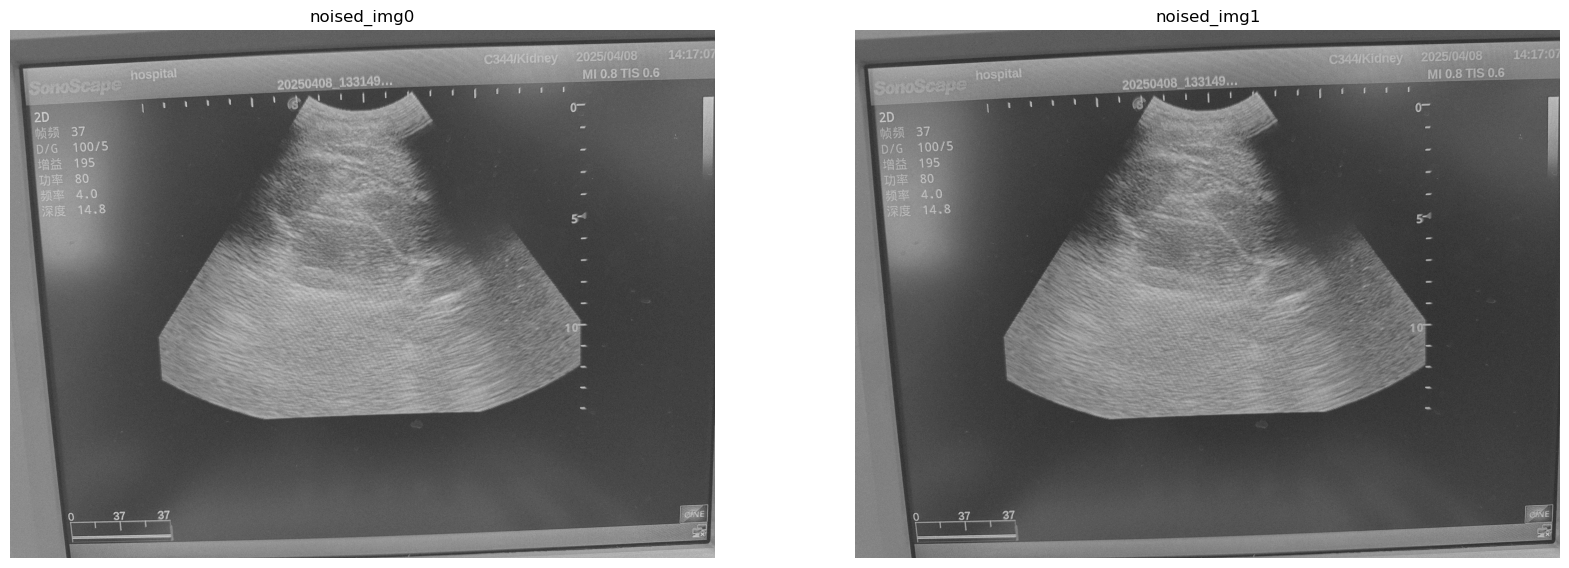

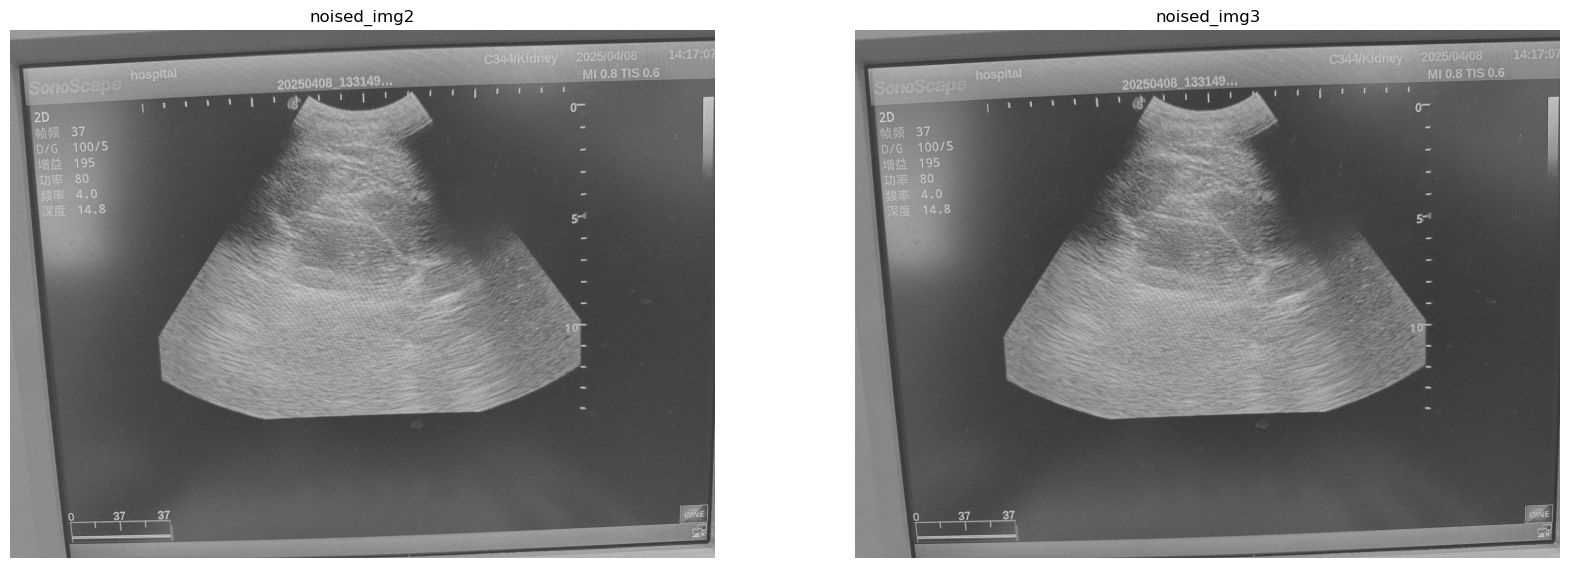

In [65]:
# 显示5张带白噪声的图片
fig, axes = plt.subplots(1, 2, figsize=(20, 10))
for i in range(2):
    axes[i].imshow(noised_img[i], cmap=plt.cm.gray)
    axes[i].set_title('noised_img{0}'.format(i))
    axes[i].axis('off')

fig, axes = plt.subplots(1, 2, figsize=(20, 10))
for i in range(2):
    axes[i].imshow(noised_img[i+2], cmap=plt.cm.gray)
    axes[i].set_title('noised_img{0}'.format(i+2))
    axes[i].axis('off')

仅展示4张，可以发现相比于原图，加噪后图像产生了明显的噪点  
下面是5帧相关图像与原图和加噪图像对比

(-0.5, 4031.5, 3023.5, -0.5)

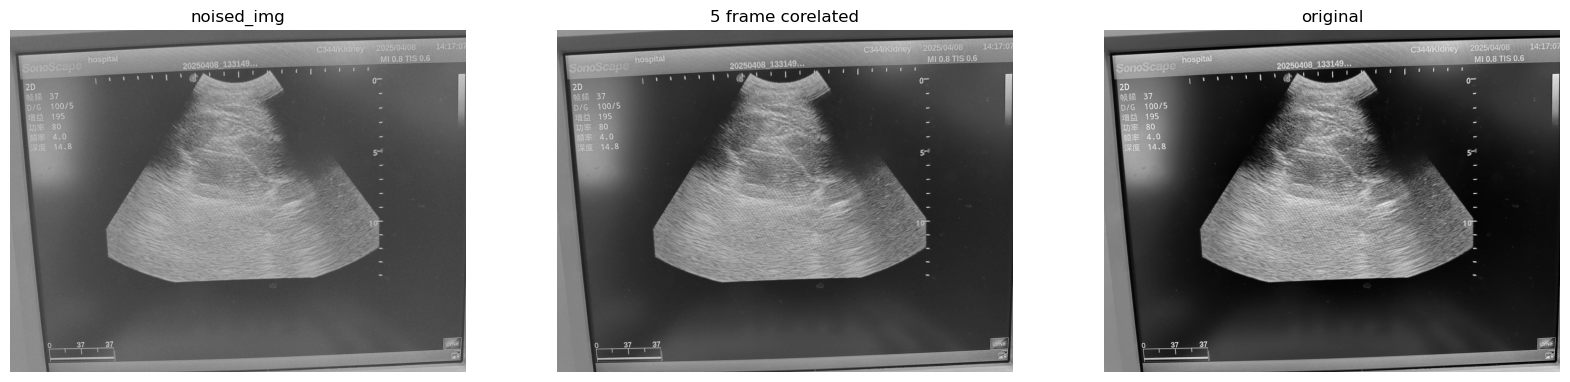

In [66]:
avg_img = np.mean(noised_img[:], axis=0)
fig, axes = plt.subplots(1, 3, figsize=(20, 10))
axes[1].imshow(avg_img, cmap=plt.cm.gray)
axes[1].set_title('5 frame corelated')
axes[1].axis('off')
axes[2].imshow(img, cmap=plt.cm.gray)
axes[2].set_title('original')
axes[2].axis('off')
axes[0].imshow(noised_img[2], cmap=plt.cm.gray)
axes[0].set_title('noised_img')
axes[0].axis('off')

可以发现帧相关后确实能去除一定的噪声，但是去噪能力有限，因为没有用功率谱，用的话可以用维纳滤波进行去噪  
下面验证标准差是否为5σ=100

In [67]:
noise = avg_img - img
sigma_noise = np.var(noise) ** 0.5
print(sigma_noise)

8.943531055556257


很显然不是，当然也不可能是5倍，假设图像为$f$，噪声为$\eta_i$，那么得到的加噪图片为
$$g_i = f + \eta_i$$
其中$\eta_i$独立同分布(i.i.d)，有
$$\forall i \,,\,\eta_i \sim \mathcal{N}(0,\sigma^2)$$
那么n帧相关后的图像就是
$$\frac{\sum_{i=1}^n g_i}{n} = f + \frac{\sum_{i=1}^n\eta_i}{n}$$
其中$\sum_{i=1}^n \eta_i \sim \mathcal{N}(0, n\sigma^2)$，那么后者也就是题目中要求的帧相关后的噪声分布为
$$\frac{\sum_{i=1}^n\eta_i}{n} \sim \mathcal{N}\left(0,\frac{\sigma^2}{n}\right)$$
带入本题数据$\sigma=20, n=5$，得到8.944

存在5倍关系的应该是均方误差(MSE)，通过表达式$MSE = |f-g|^2$不难发现，MSE就是噪声的平方的期望  
由于存在关系$D(x) = E(x^2) - E^2(x)$，且本题为白噪声，$E(x)=0$  
因此，在加噪后的均方误差就是$E(\eta_i^2)=\sigma^2$，而帧相关后的均方误差就是$\frac{\sigma^2}{n}$  
下面进行理论验证

In [68]:
MSE_1 = np.sum((img-noised_img[2])**2) / img.shape[0] / img.shape[1]
MSE_2 = np.sum((avg_img-img)**2) / img.shape[0] / img.shape[1]
print('帧相关前的MSE为{0}，帧相关后的MSE为{1}'.format(MSE_1, MSE_2))

帧相关前的MSE为400.2711010330058，帧相关后的MSE为79.98674624170657


验证完成，理论正确